# S&P 500 Price Prediction - Baseline Approach

**Description**: This notebook represents the first attempt to predict the S&P 500 closing prices using XGBoost. The model is trained on absolute price values. <br>
**Note**: As seen in the final plot, this approach suffers from an extrapolation limit; because tree-based models cannot predict values higher than those seen during training, the prediction "flattens out" when the market reaches new historical highs in 2024.

**Data Loading and Cleaning**

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load the dataset
df = pd.read_csv('financial_regression.csv', parse_dates=['date']).sort_values("date")

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

# Filter data from 2010-04-01 onwards based on EDA consistency
df = df[df["date"] >= "2010-04-01"].reset_index(drop=True)

# Apply forward fill to macroeconomic data (propagate last known value)
macro_cols = ["GDP", "CPI", "us_rates_%"]
existing_macro = [c for c in macro_cols if c in df.columns]
df[existing_macro] = df[existing_macro].ffill()

# Define the target variable
TARGET = 'sp500 close'

# Drop rows where the target is missing
df.dropna(subset=[TARGET], inplace=True)

# Set date as index for time-series operations
df.set_index('date', inplace=True)

print(f"Data loaded. Range: {df.index.min().date()} to {df.index.max().date()}")

Data loaded. Range: 2010-04-01 to 2024-10-23


**Feature Engineering**

In [23]:
# 1. Lag Features: Yesterday's price is a strong predictor for today
df['sp500_lag1'] = df[TARGET].shift(1)
df['sp500_lag3'] = df[TARGET].shift(3)
df['sp500_lag7'] = df[TARGET].shift(7)

# 2. Rolling Windows: Capturing recent trends and volatility
df['sp500_roll_mean7'] = df[TARGET].rolling(window=7).mean()
df['sp500_roll_std7'] = df[TARGET].rolling(window=7).std()
df['sp500_roll_mean30'] = df[TARGET].rolling(window=30).mean()

# 3. Drop NaNs created by shifts and rolling windows
df.dropna(inplace=True)

**Train/Test Split and Model Training**

In [24]:
# 1. Split: Training until 2021, Testing from 2022 onwards
train = df[df.index < '2022-01-01']
test = df[df.index >= '2022-01-01']

# 2. Define features available in the dataset
FEATURES = [
    'us_rates_%', 'CPI', 'GDP',              # Macro factors
    'sp500_lag1', 'sp500_lag3', 'sp500_lag7', # Lagged prices
    'sp500_roll_mean7', 'sp500_roll_std7',    # Rolling stats
    'nasdaq close', 'usd_chf', 'eur_usd',    # Correlated assets
    'silver close', 'oil close', 'gold close'
]
FEATURES = [f for f in FEATURES if f in df.columns]

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

# 3. Initialize XGBoost with Early Stopping
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
    n_jobs=-1
)

print("Training model...")
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=100)

Training model...
[0]	validation_0-rmse:86.78681	validation_1-rmse:226.24093
[100]	validation_0-rmse:32.31985	validation_1-rmse:103.58030
[200]	validation_0-rmse:12.17917	validation_1-rmse:59.33019
[300]	validation_0-rmse:4.82078	validation_1-rmse:43.78243
[400]	validation_0-rmse:2.31612	validation_1-rmse:38.21645
[500]	validation_0-rmse:1.58816	validation_1-rmse:35.85176
[600]	validation_0-rmse:1.38097	validation_1-rmse:34.86639
[700]	validation_0-rmse:1.28565	validation_1-rmse:34.49868
[800]	validation_0-rmse:1.22553	validation_1-rmse:34.35864
[900]	validation_0-rmse:1.17486	validation_1-rmse:34.30785
[999]	validation_0-rmse:1.13014	validation_1-rmse:34.28516


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,None


**Visualization and "The Flattening" Problem**

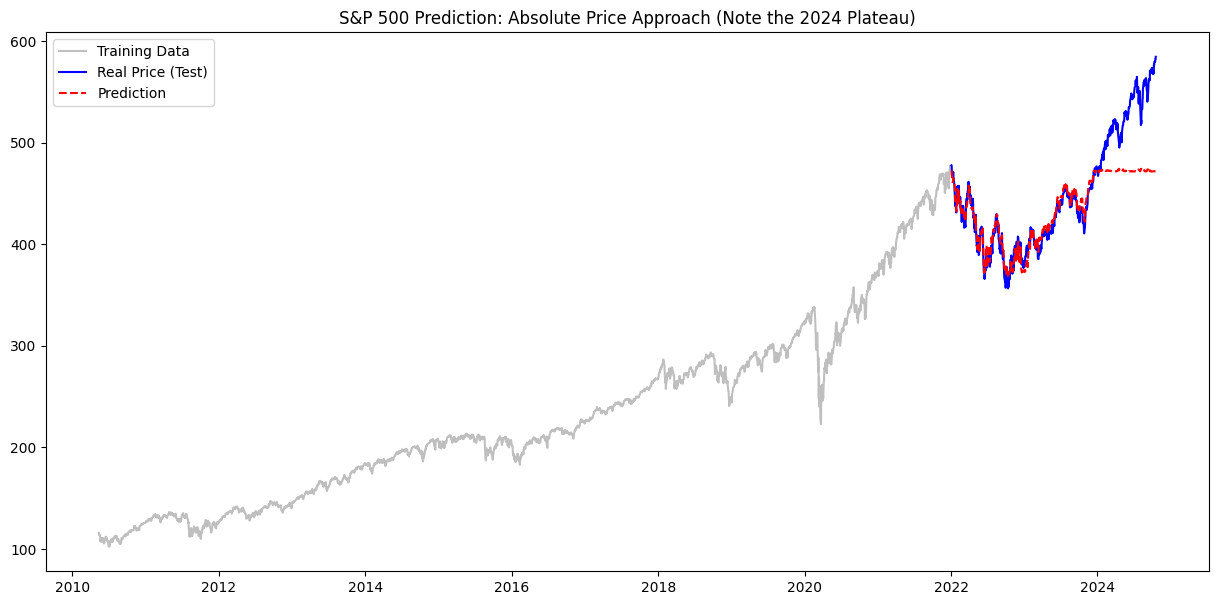

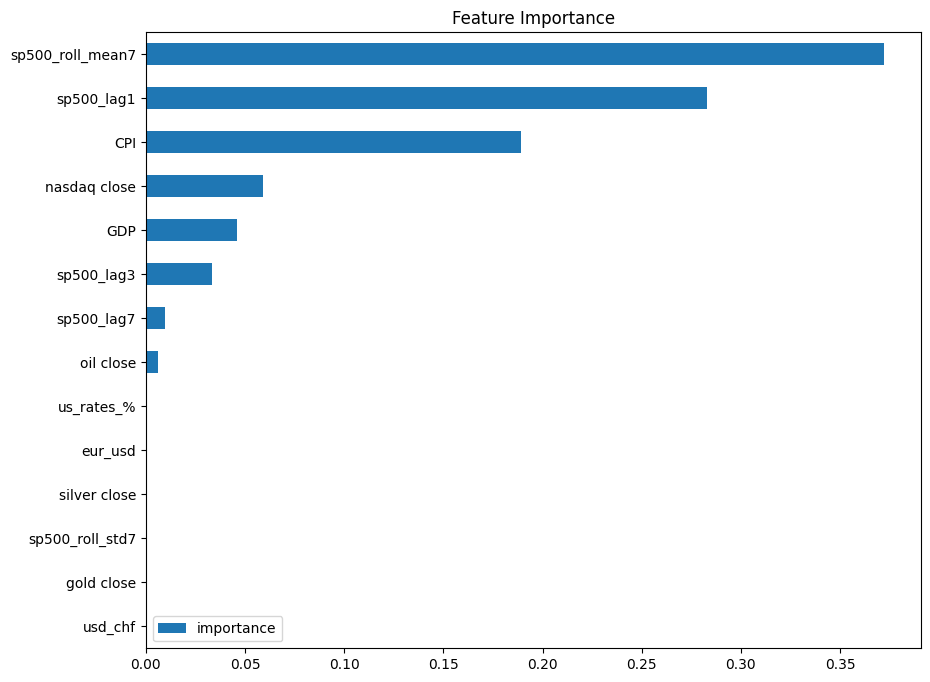

In [25]:
# Predictions
test = test.copy()
test['prediction'] = model.predict(X_test)

# Plot results
plt.figure(figsize=(15, 7))
plt.plot(train.index, train[TARGET], label='Training Data', color='gray', alpha=0.5)
plt.plot(test.index, test[TARGET], label='Real Price (Test)', color='blue')
plt.plot(test.index, test['prediction'], label='Prediction', color='red', linestyle='--')
plt.title('S&P 500 Prediction: Absolute Price Approach (Note the 2024 Plateau)')
plt.legend()
plt.show()

# Feature Importance
fi = pd.DataFrame(data=model.feature_importances_, index=model.feature_names_in_, columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance', figsize=(10,8))
plt.show()